# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
from sklearn.metrics import accuracy_score
import pandas as pd
from hw2code import *
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

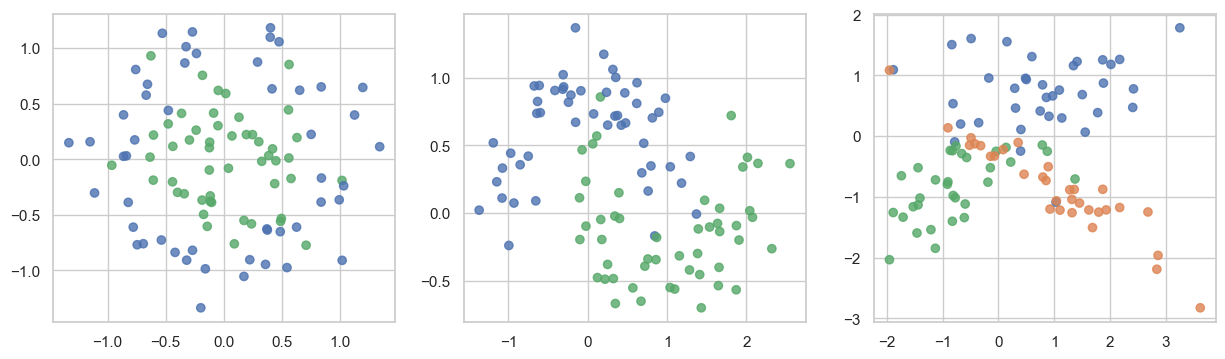

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

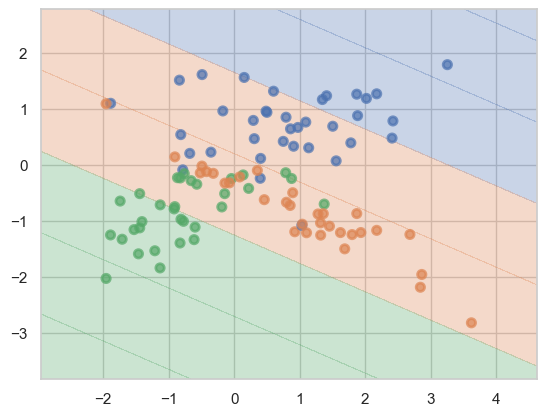

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

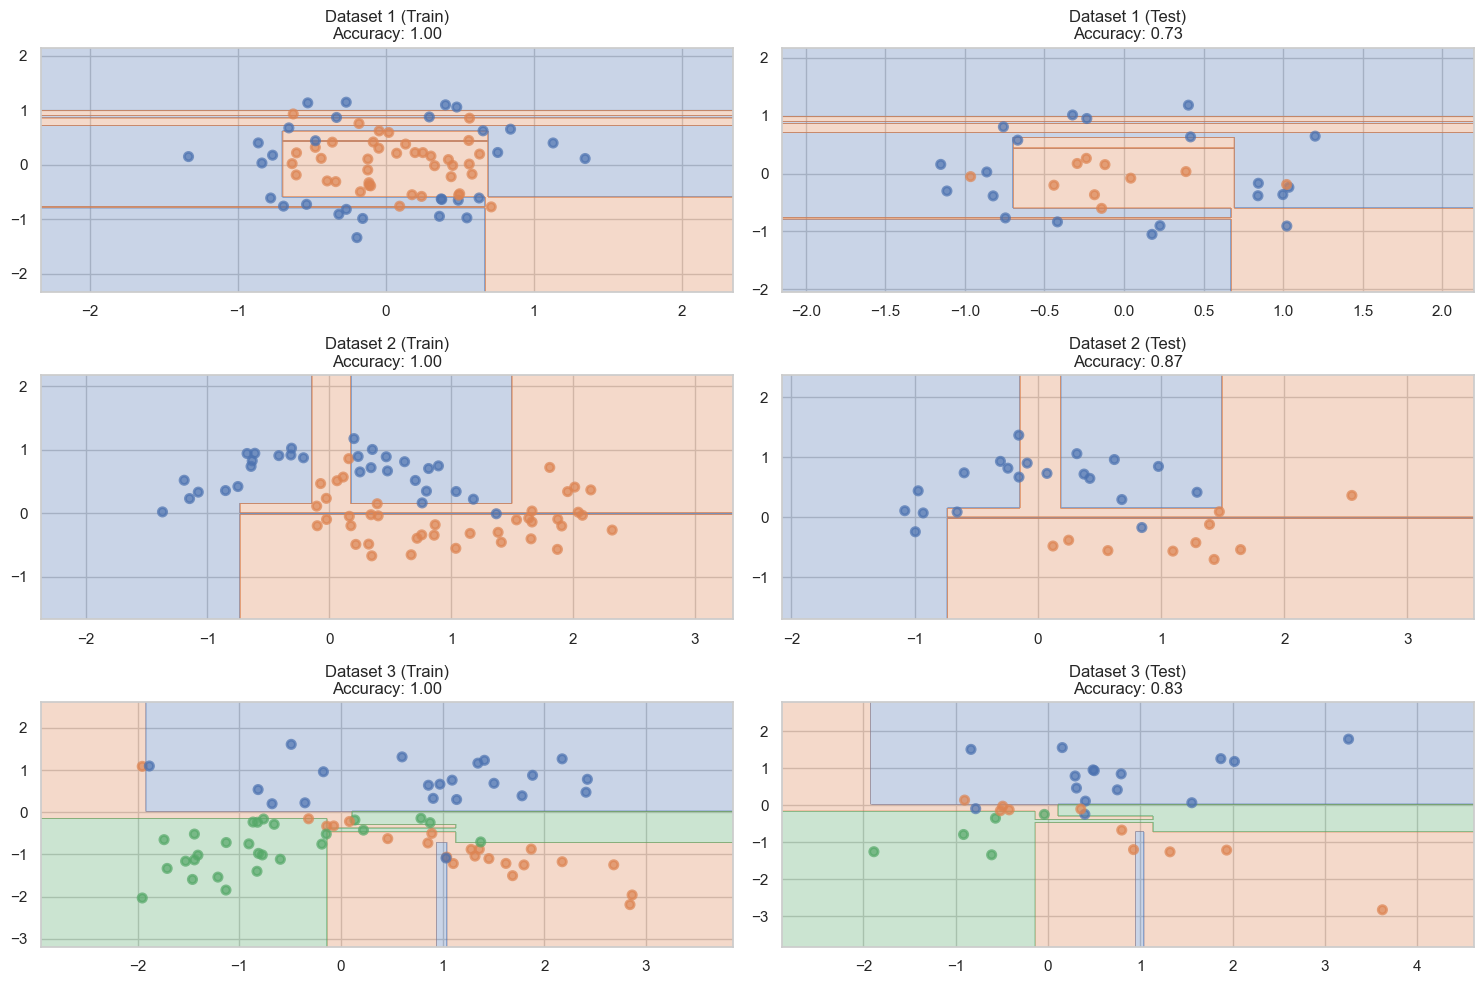

In [7]:
plt.figure(figsize=(15, 10))
for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    
    plt.subplot(3, 2, 2*i+1)
    plot_surface(tree, X_train, y_train)
    plt.title(f'Dataset {i+1} (Train)\nAccuracy: {train_acc:.2f}')
    
    plt.subplot(3, 2, 2*i+2)
    plot_surface(tree, X_test, y_test)
    plt.title(f'Dataset {i+1} (Test)\nAccuracy: {test_acc:.2f}')

plt.tight_layout()
plt.show()

__Ответ:__ 
Решающие деревья с параметрами по умолчанию демонстрируют сильное переобучение на всех трех датасетах. Они достигают 100% accuracy на обучающей выборке, но значительно хуже работают на тестовых данных. Особенно это заметно на сложных нелинейных датасетах

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


=== Анализ датасета: Circles ===


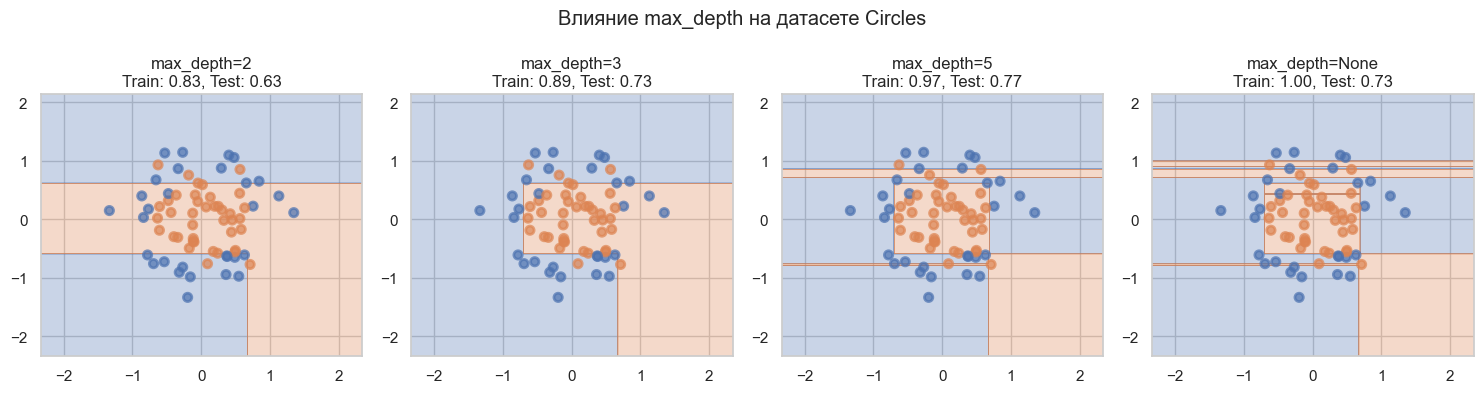

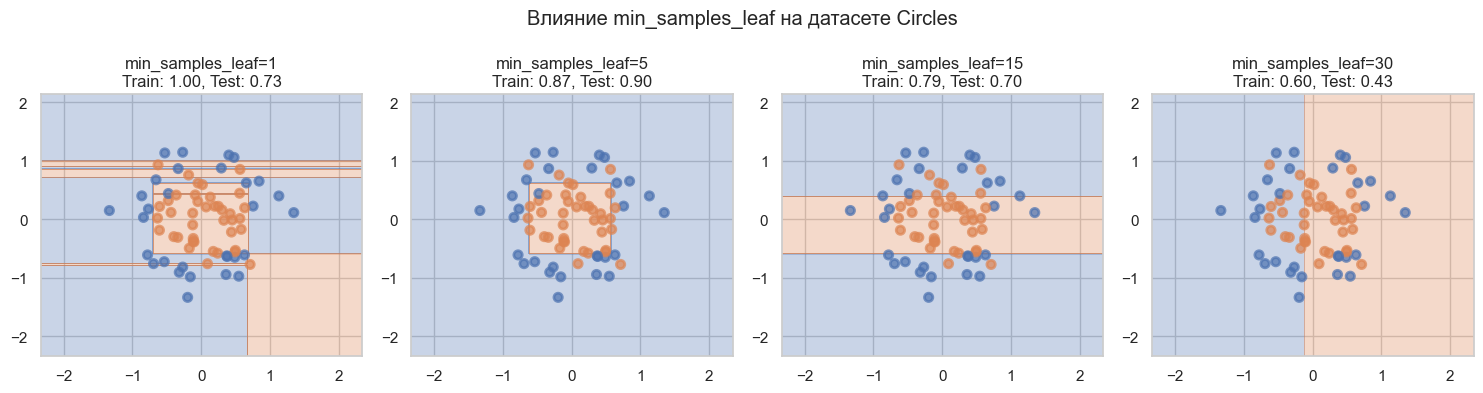


=== Анализ датасета: Moons ===


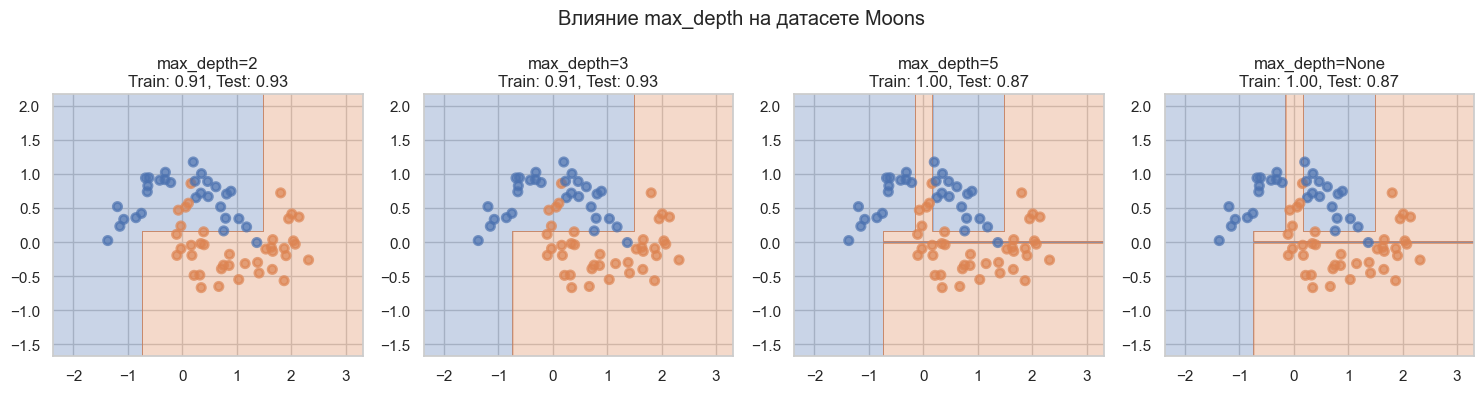

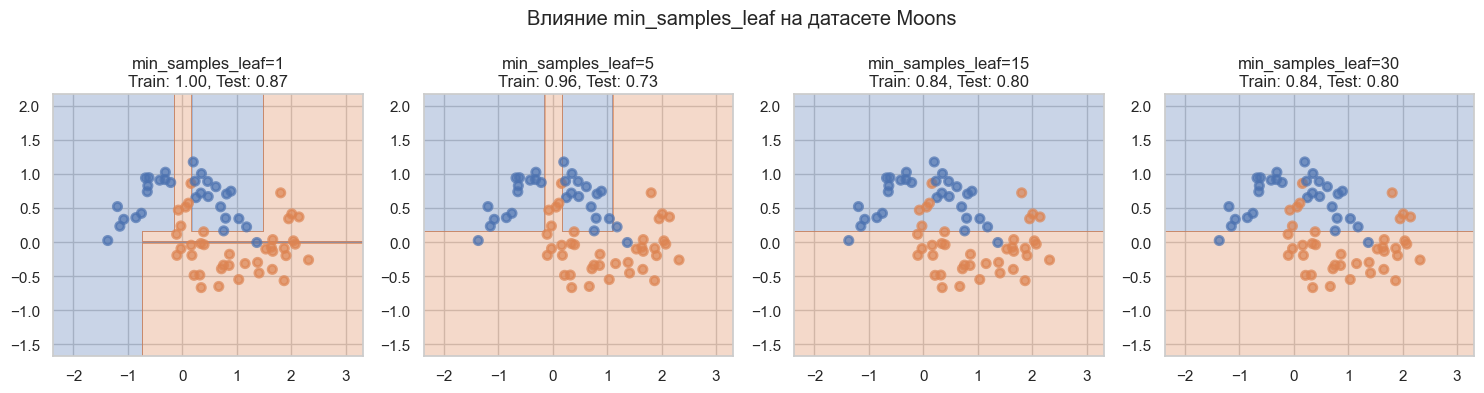


=== Анализ датасета: 3 Classes ===


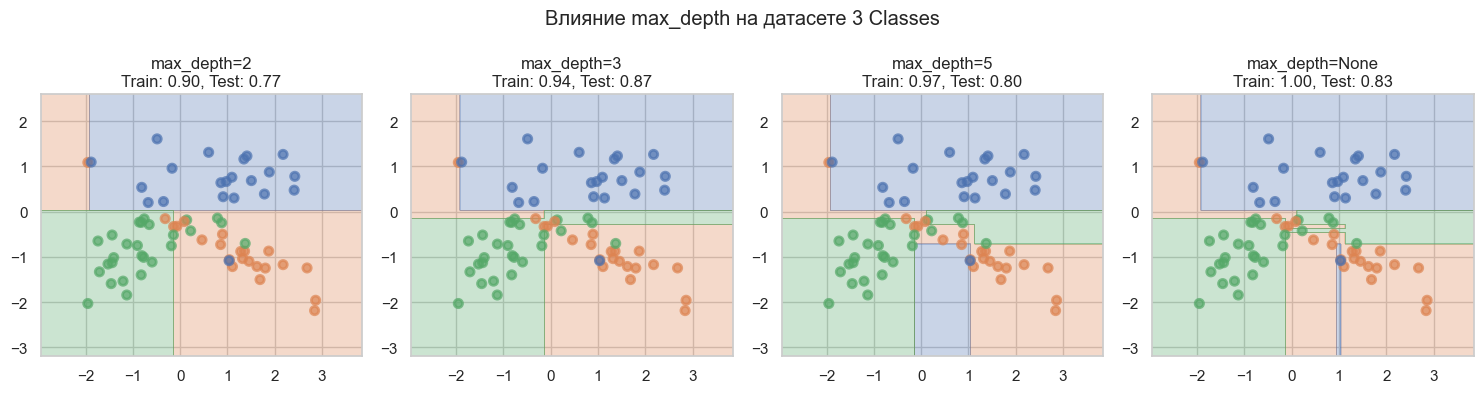

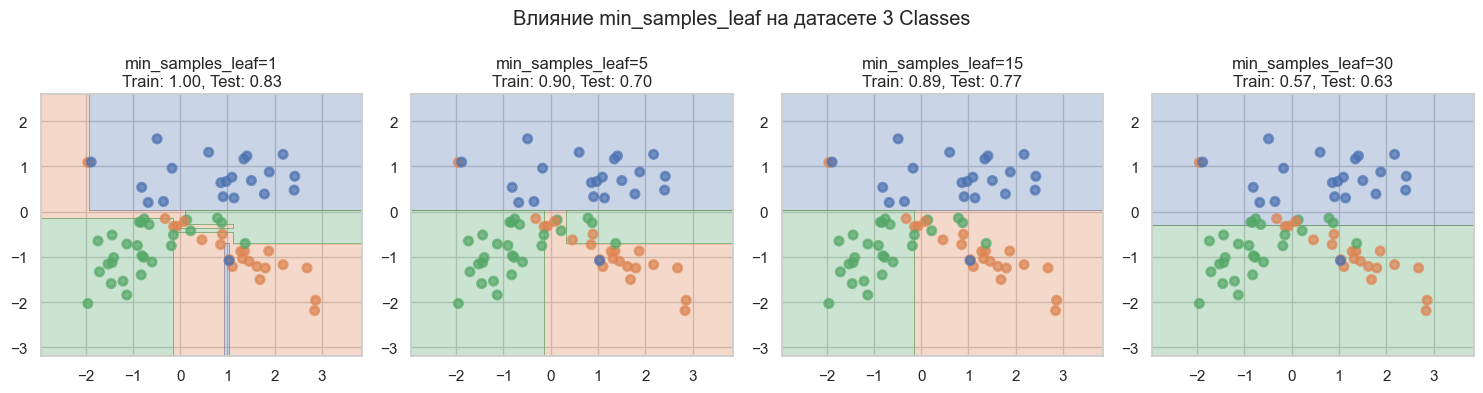

In [8]:
dataset_names = ["Circles", "Moons", "3 Classes"]

max_depths = [2, 3, 5, None]
min_samples_leaves = [1, 5, 15, 30]

random_state = 42

# Полный анализ для каждого датасета
for dataset_idx, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state)
    
    print(f"\n=== Анализ датасета: {dataset_names[dataset_idx]} ===")
    
    plt.figure(figsize=(15, 4))
    for i, max_depth in enumerate(max_depths):
        tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=1, 
                                   random_state=random_state)
        tree.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, tree.predict(X_train))
        test_acc = accuracy_score(y_test, tree.predict(X_test))
        
        ax = plt.subplot(1, 4, i+1)
        title=f"max_depth={max_depth}\nTrain: {train_acc:.2f}, Test: {test_acc:.2f}"
        plt.title(title)
        plot_surface(tree, X_train, y_train)

    plt.suptitle(f"Влияние max_depth на датасете {dataset_names[dataset_idx]}")
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(15, 4))
    for i, min_samples_leaf in enumerate(min_samples_leaves):
        tree = DecisionTreeClassifier(max_depth=None, min_samples_leaf=min_samples_leaf,
                                    random_state=random_state)
        tree.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, tree.predict(X_train))
        test_acc = accuracy_score(y_test, tree.predict(X_test))
        
        ax = plt.subplot(1, 4, i+1)
        title=f"min_samples_leaf={min_samples_leaf}\nTrain: {train_acc:.2f}, Test: {test_acc:.2f}"
        plt.title(title)
        plot_surface(tree, X_train, y_train)
    
    plt.suptitle(f"Влияние min_samples_leaf на датасете {dataset_names[dataset_idx]}")
    plt.tight_layout()
    plt.show()

__Ответ:__ 
С ростом глубины дерева и уменьшением числа объектов в листе, модель строит всё более запутанную границу между классами

На первом наборе данных (circles) наблюдается случай переобучения. На втором (moons) поведение нестабильно. В третьем случае (classification) видно улучшение, за которым следует ухудшение.

Таким образом, чрезмерная сложность модели ухудшает её обобщающую способность, особенно это заметно на данных с нечёткой границей между классами.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

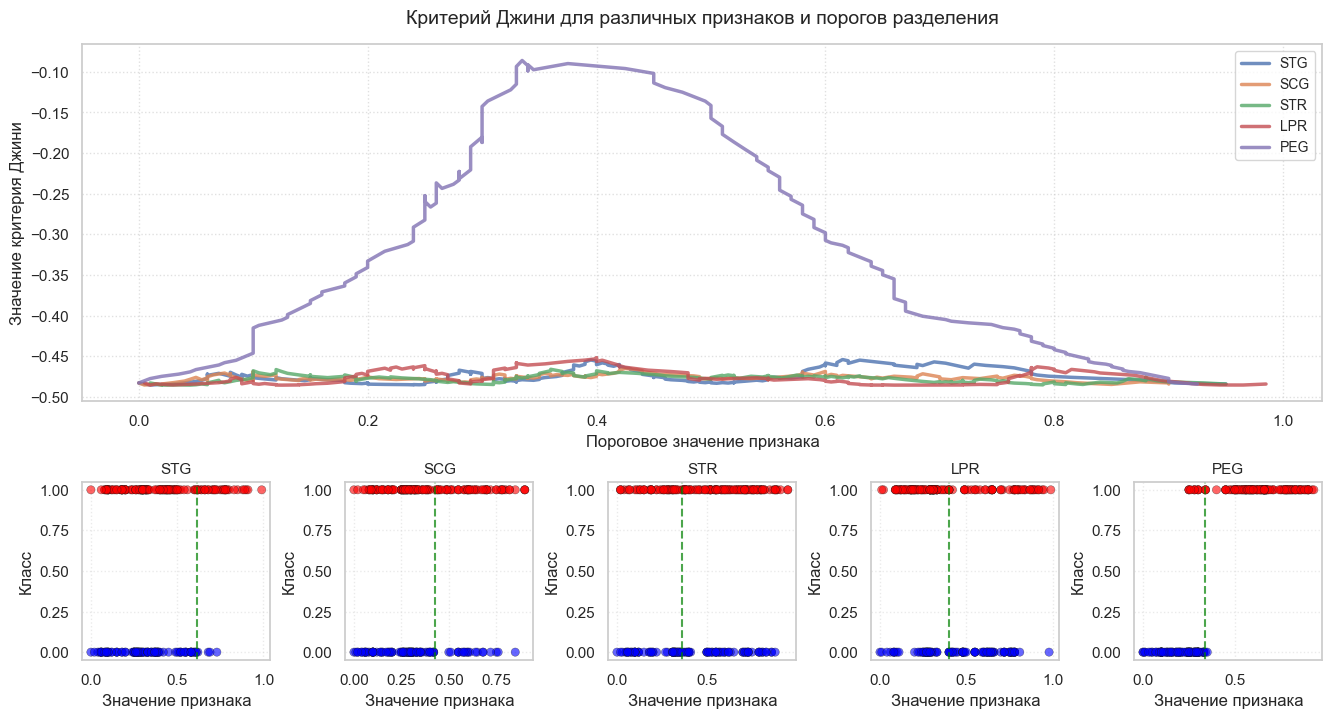

In [9]:
from matplotlib.gridspec import GridSpec

data = pd.read_csv('datasets/students.csv')
features = data.iloc[:, :5].values
target = data.iloc[:, -1].values

if isinstance(target[0], str):
    target = np.where(target == 'High', 1, 0)

plt.figure(figsize=(16, 8))
gs = GridSpec(2, 5, height_ratios=[2, 1], hspace=0.3, wspace=0.4)

ax_main = plt.subplot(gs[0, :])
feature_names = data.columns[:5]

for i, name in enumerate(feature_names):
    feature = features[:, i]
    thresholds, ginis, _, _ = find_best_split(feature, target)
    
    if thresholds is not None and ginis is not None:
        ax_main.plot(thresholds, ginis, label=name, linewidth=2.5, alpha=0.8)

ax_main.set_title('Критерий Джини для различных признаков и порогов разделения', fontsize=14, pad=15)
ax_main.set_xlabel('Пороговое значение признака', fontsize=12)
ax_main.set_ylabel('Значение критерия Джини', fontsize=12)
ax_main.legend(loc='upper right', fontsize=10)
ax_main.grid(True, linestyle=':', alpha=0.6)

for i, name in enumerate(feature_names):
    ax = plt.subplot(gs[1, i])
    ax.scatter(features[:, i], target, alpha=0.6, c=target, cmap='bwr', edgecolor='k', linewidth=0.3)
    
    thresholds, _, best_thresh, _ = find_best_split(features[:, i], target)
    if best_thresh is not None:
        ax.axvline(x=best_thresh, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Класс')
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**
Судя по кривым Джини, признак PEG показывает наибольшее (наименее отрицательное) значение критерия Джини, что делает его лучшим кандидатом для первого разделения выборки. Это полностью согласуется с визуальной оценкой scatter-графика для PEG, где наблюдается четкое разделение классов.

Форма кривой напоминает симметричный холм с ярко выраженным минимумом по краям, четким пиком в оптимальной точке разделения, большой площадью под кривой

Характеристики плохих признаков: плоские, почти горизонтальные кривые, отсутствие четкого пика, малая площадь под кривой, незначительные колебания значений Джини

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
           'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
           'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
           'stalk-surface-below-ring', 'stalk-color-above-ring',
           'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
           'ring-type', 'spore-print-color', 'population', 'habitat']
data = pd.read_csv('datasets/agaricus-lepiota.data', names=columns)

le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data.drop('class', axis=1).values
y = data['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

feature_types = ['categorical'] * X.shape[1]  # Все признаки категориальные
tree = DecisionTree(feature_types=feature_types, max_depth=3)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Глубина дерева: {tree.get_tree_depth()}")

Accuracy: 0.9968
Глубина дерева: 4


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

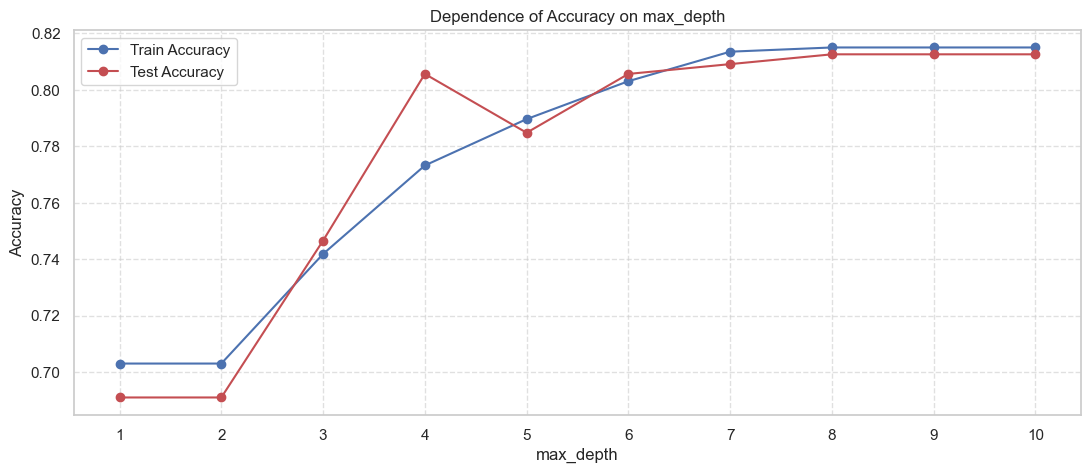

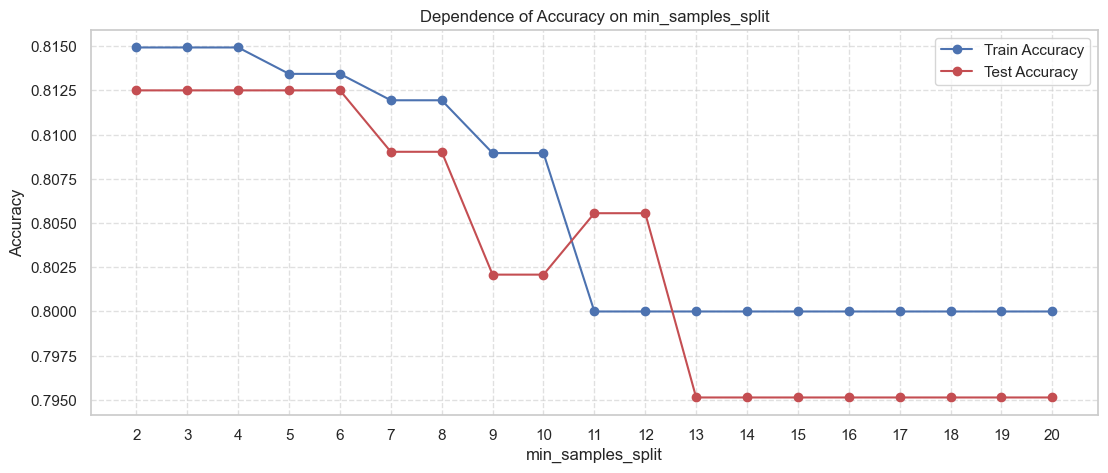

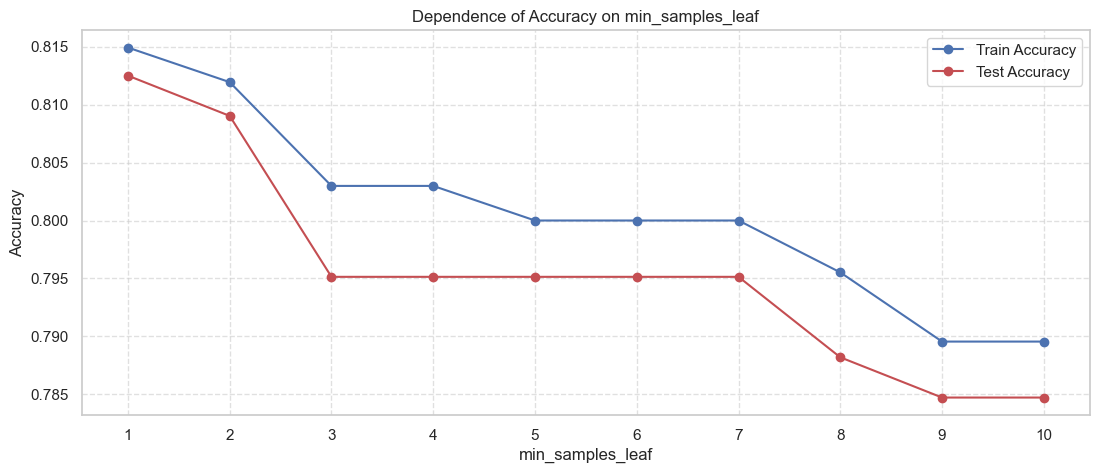

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

tic_tac_toe = pd.read_csv('datasets/tic-tac-toe-endgame.csv')
X = tic_tac_toe.iloc[:, :-1].apply(LabelEncoder().fit_transform).values
y = (tic_tac_toe.iloc[:, -1] == 'positive').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
feature_types = ['categorical'] * X.shape[1]  # Все признаки категориальные

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
def evaluate_param(param_name, param_values):
    train_acc = []
    test_acc = []
    for value in param_values:
        params = {
            'max_depth': 10 if param_name != 'max_depth' else value,
            'min_samples_split': 2 if param_name != 'min_samples_split' else value,
            'min_samples_leaf': 1 if param_name != 'min_samples_leaf' else value,
        }
        tree = DecisionTree(feature_types=feature_types, **params)
        tree.fit(X_train, y_train)

        y_train_pred = tree.predict(X_train)
        y_test_pred = tree.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
    
    plt.figure(figsize=(13, 5))
    plt.plot(param_values, train_acc, 'b-o', label='Train Accuracy')
    plt.plot(param_values, test_acc, 'r-o', label='Test Accuracy')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.title(f'Dependence of Accuracy on {param_name}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(param_values)
    plt.show()

evaluate_param('max_depth', range(1, 11))
evaluate_param('min_samples_split', range(2, 21)) 
evaluate_param('min_samples_leaf', range(1, 11)) 

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier as SkTree

class RealValuedTree:
    def fit(self, X, y):
        features = X.to_numpy().astype(float) if hasattr(X, 'to_numpy') else X
        targets = y.to_numpy() if hasattr(y, 'to_numpy') else y
        self.tree = DecisionTree(['real'] * X.shape[1])
        self.tree.fit(features, targets)
        return self

    def predict(self, X):
        return self.tree.predict(X.to_numpy().astype(float) if hasattr(X, 'to_numpy') else X)

    def get_params(self, deep=True):
        return {}


class CategoricalTree:
    def fit(self, X, y):
        features = X.to_numpy() if hasattr(X, 'to_numpy') else X
        targets = y.to_numpy() if hasattr(y, 'to_numpy') else y
        self.tree = DecisionTree(['categorical'] * X.shape[1])
        self.tree.fit(features, targets)
        return self

    def predict(self, X):
        return self.tree.predict(X.to_numpy() if hasattr(X, 'to_numpy') else X)

    def get_params(self, deep=True):
        return {}


class OneHotTree:
    def __init__(self):
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    def fit(self, X, y):
        features = X.to_numpy() if hasattr(X, 'to_numpy') else X
        targets = y.to_numpy() if hasattr(y, 'to_numpy') else y
        self.encoder.fit(features)
        X_encoded = self.encoder.transform(features)
        self.tree = DecisionTree(['real'] * X_encoded.shape[1])
        self.tree.fit(X_encoded, targets)
        return self

    def predict(self, X):
        features = X.to_numpy() if hasattr(X, 'to_numpy') else X
        return self.tree.predict(self.encoder.transform(features))

    def get_params(self, deep=True):
        return {}


data_sources = {
    'mushroom': ('datasets/agaricus-lepiota.data', None),
    'tic_tac_toe': ('datasets/tic-tac-toe-endgame.csv', None),
    'car': ('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', None),
    'nursery': ('https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data', None)
}

label_transforms = {
    'mushroom': lambda df: df.assign(target=df[0].map({'p': 0, 'e': 1})).dropna(subset=['target']).drop(columns=0),
    'tic_tac_toe': lambda df: df.assign(target=df[df.columns[-1]].map({'negative': 0, 'positive': 1})).dropna(subset=['target']).drop(columns=df.columns[-1]),
    'car': lambda df: df.assign(target=df[df.columns[-1]].map({'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1})).dropna(subset=['target']).drop(columns=df.columns[-1]),
    'nursery': lambda df: df.assign(target=df[df.columns[-1]].map({
        'not_recom': 0, 'recommend': 0, 'very_recom': 1, 'priority': 1, 'spec_prior': 1
    })).dropna(subset=['target']).drop(columns=df.columns[-1])
}

datasets = {}
for name, (path, _) in data_sources.items():
    df = pd.read_csv(path, header=None)
    df = label_transforms[name](df)
    target = df['target']
    features = df.drop(columns='target')
    labeler = LabelEncoder()
    for col in features.columns:
        features[col] = labeler.fit_transform(features[col].astype(str))
    datasets[name] = (features, target)

model_variants = [
    ('Continuous', RealValuedTree()),
    ('Discrete', CategoricalTree()),
    ('OneHotEnc', OneHotTree()),
    ('SklearnTree', SkTree())
]

results = []
for dataset_name, (X, y) in datasets.items():
    scores_record = {'Dataset': dataset_name}
    for label, model in model_variants:
        scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
        scores_record[label] = scores.mean()
    results.append(scores_record)

score_df = pd.DataFrame(results).set_index('Dataset')
pd.options.display.float_format = '{:.4f}'.format
print("Сравнительная точность моделей по датасетам:")
print(score_df)

Сравнительная точность моделей по датасетам:
             Continuous  Discrete  OneHotEnc  SklearnTree
Dataset                                                  
mushroom         0.2108    0.9961     0.4128       0.9611
tic_tac_toe      0.2427    0.5563     0.6521       0.7478
car              0.9223    0.9635     0.9223       0.9427
nursery          0.9998    0.9998     0.9998       0.9997


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**
Ранжирование алгоритмов варьируется между датасетами: например, в mushroom и car дискретная модель работает лучше, а в tic_tac_toe преимущество у OneHot. Это связано с природой признаков — где важны категориальные значения, методы, сохраняющие дискретную структуру, показывают лучшие результаты.

Вставьте что угодно, описывающее ваши впечатления от этого задания: